# Advanced Supervised Models

Implements the Decision Tree Regressor, Gaussian Naive Bayes, and Support Vector Regressor for Regression problems

### Data Exploration and Cleaning

- Load the dataset

In [248]:
# Upload the dataset
from google.colab import files
uploaded = files.upload()

Saving boston_housing.csv to boston_housing.csv


In [249]:
# Get the dataset name
import os
dataset_name = ""
for fn in uploaded.keys():
  dataset_name = fn
print(dataset_name)

boston_housing.csv


In [250]:
import pandas as pd
from sklearn.model_selection import train_test_split
# Load the dataset
df = pd.read_csv(dataset_name)
df

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273,21.0,391.99,9.67,22.4
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273,21.0,393.45,6.48,22.0


In [251]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    int64  
 4   nox      506 non-null    float64
 5   rm       506 non-null    float64
 6   age      506 non-null    float64
 7   dis      506 non-null    float64
 8   rad      506 non-null    int64  
 9   tax      506 non-null    int64  
 10  ptratio  506 non-null    float64
 11  black    506 non-null    float64
 12  lstat    506 non-null    float64
 13  medv     506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB


### Data Visualization
- Shows data distribution using Histograms and Box Plots
- Shows correlation using a heatmap

In [252]:
import matplotlib.pyplot as plt
import seaborn as sns

def generate_plot(df, plot):
  features = df.columns.tolist()
  # Calculate the number of rows needed based on the number of features and 2 columns
  num_features = len(features)
  num_rows = (num_features + 1) // 2 # +1 for ceiling division

  # Create a single figure with a grid of subplots
  fig, axes = plt.subplots(num_rows, 2, figsize=(15, 4 * num_rows))
  axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

  print("Generating the plot for each feature...")
  # Iterate through features and plot each histogram
  for i, k in enumerate(features):
    if plot == 'histogram':
      sns.histplot(data=df, x=k, ax=axes[i])
    if plot == 'boxplot':
      sns.boxplot(data=df, x=k, ax=axes[i])
    axes[i].set_ylabel('Frequency')
    axes[i].set_title(f'Distribution of {k}') # Add title for each subplot

  # Hide any unused subplots
  for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

  plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
  plt.show()


Generating the plot for each feature...


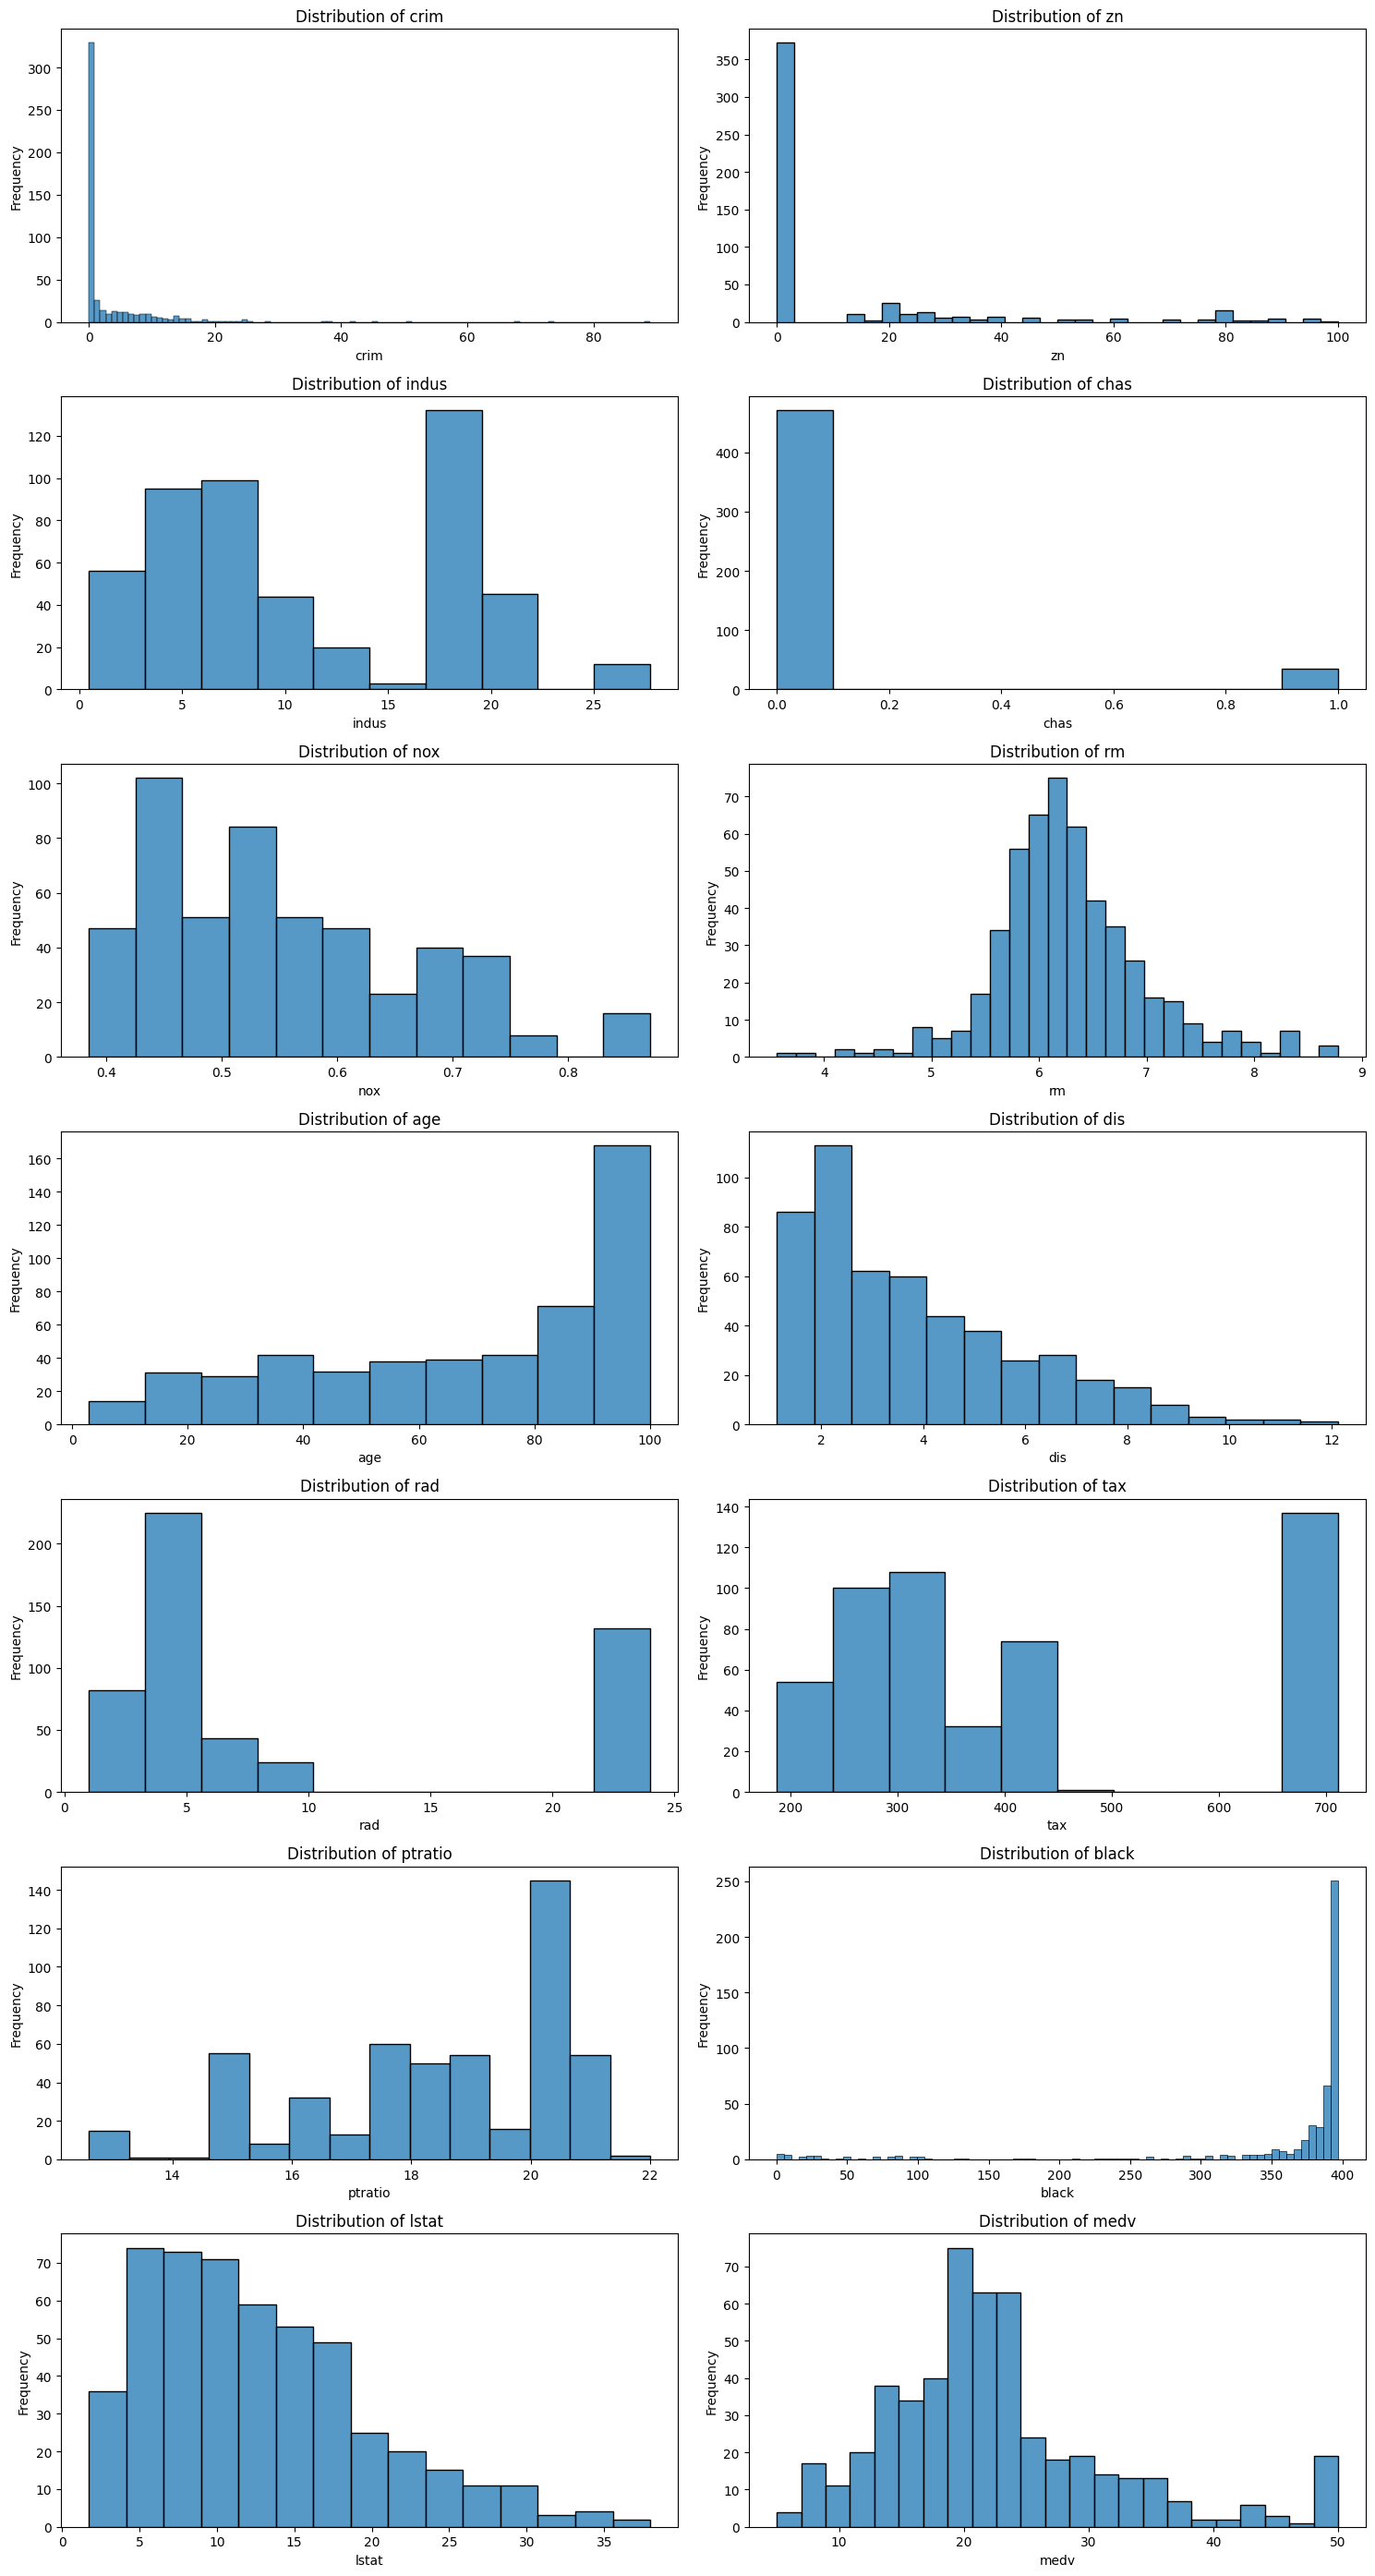

In [253]:
generate_plot(df, plot='histogram')

Generating the plot for each feature...


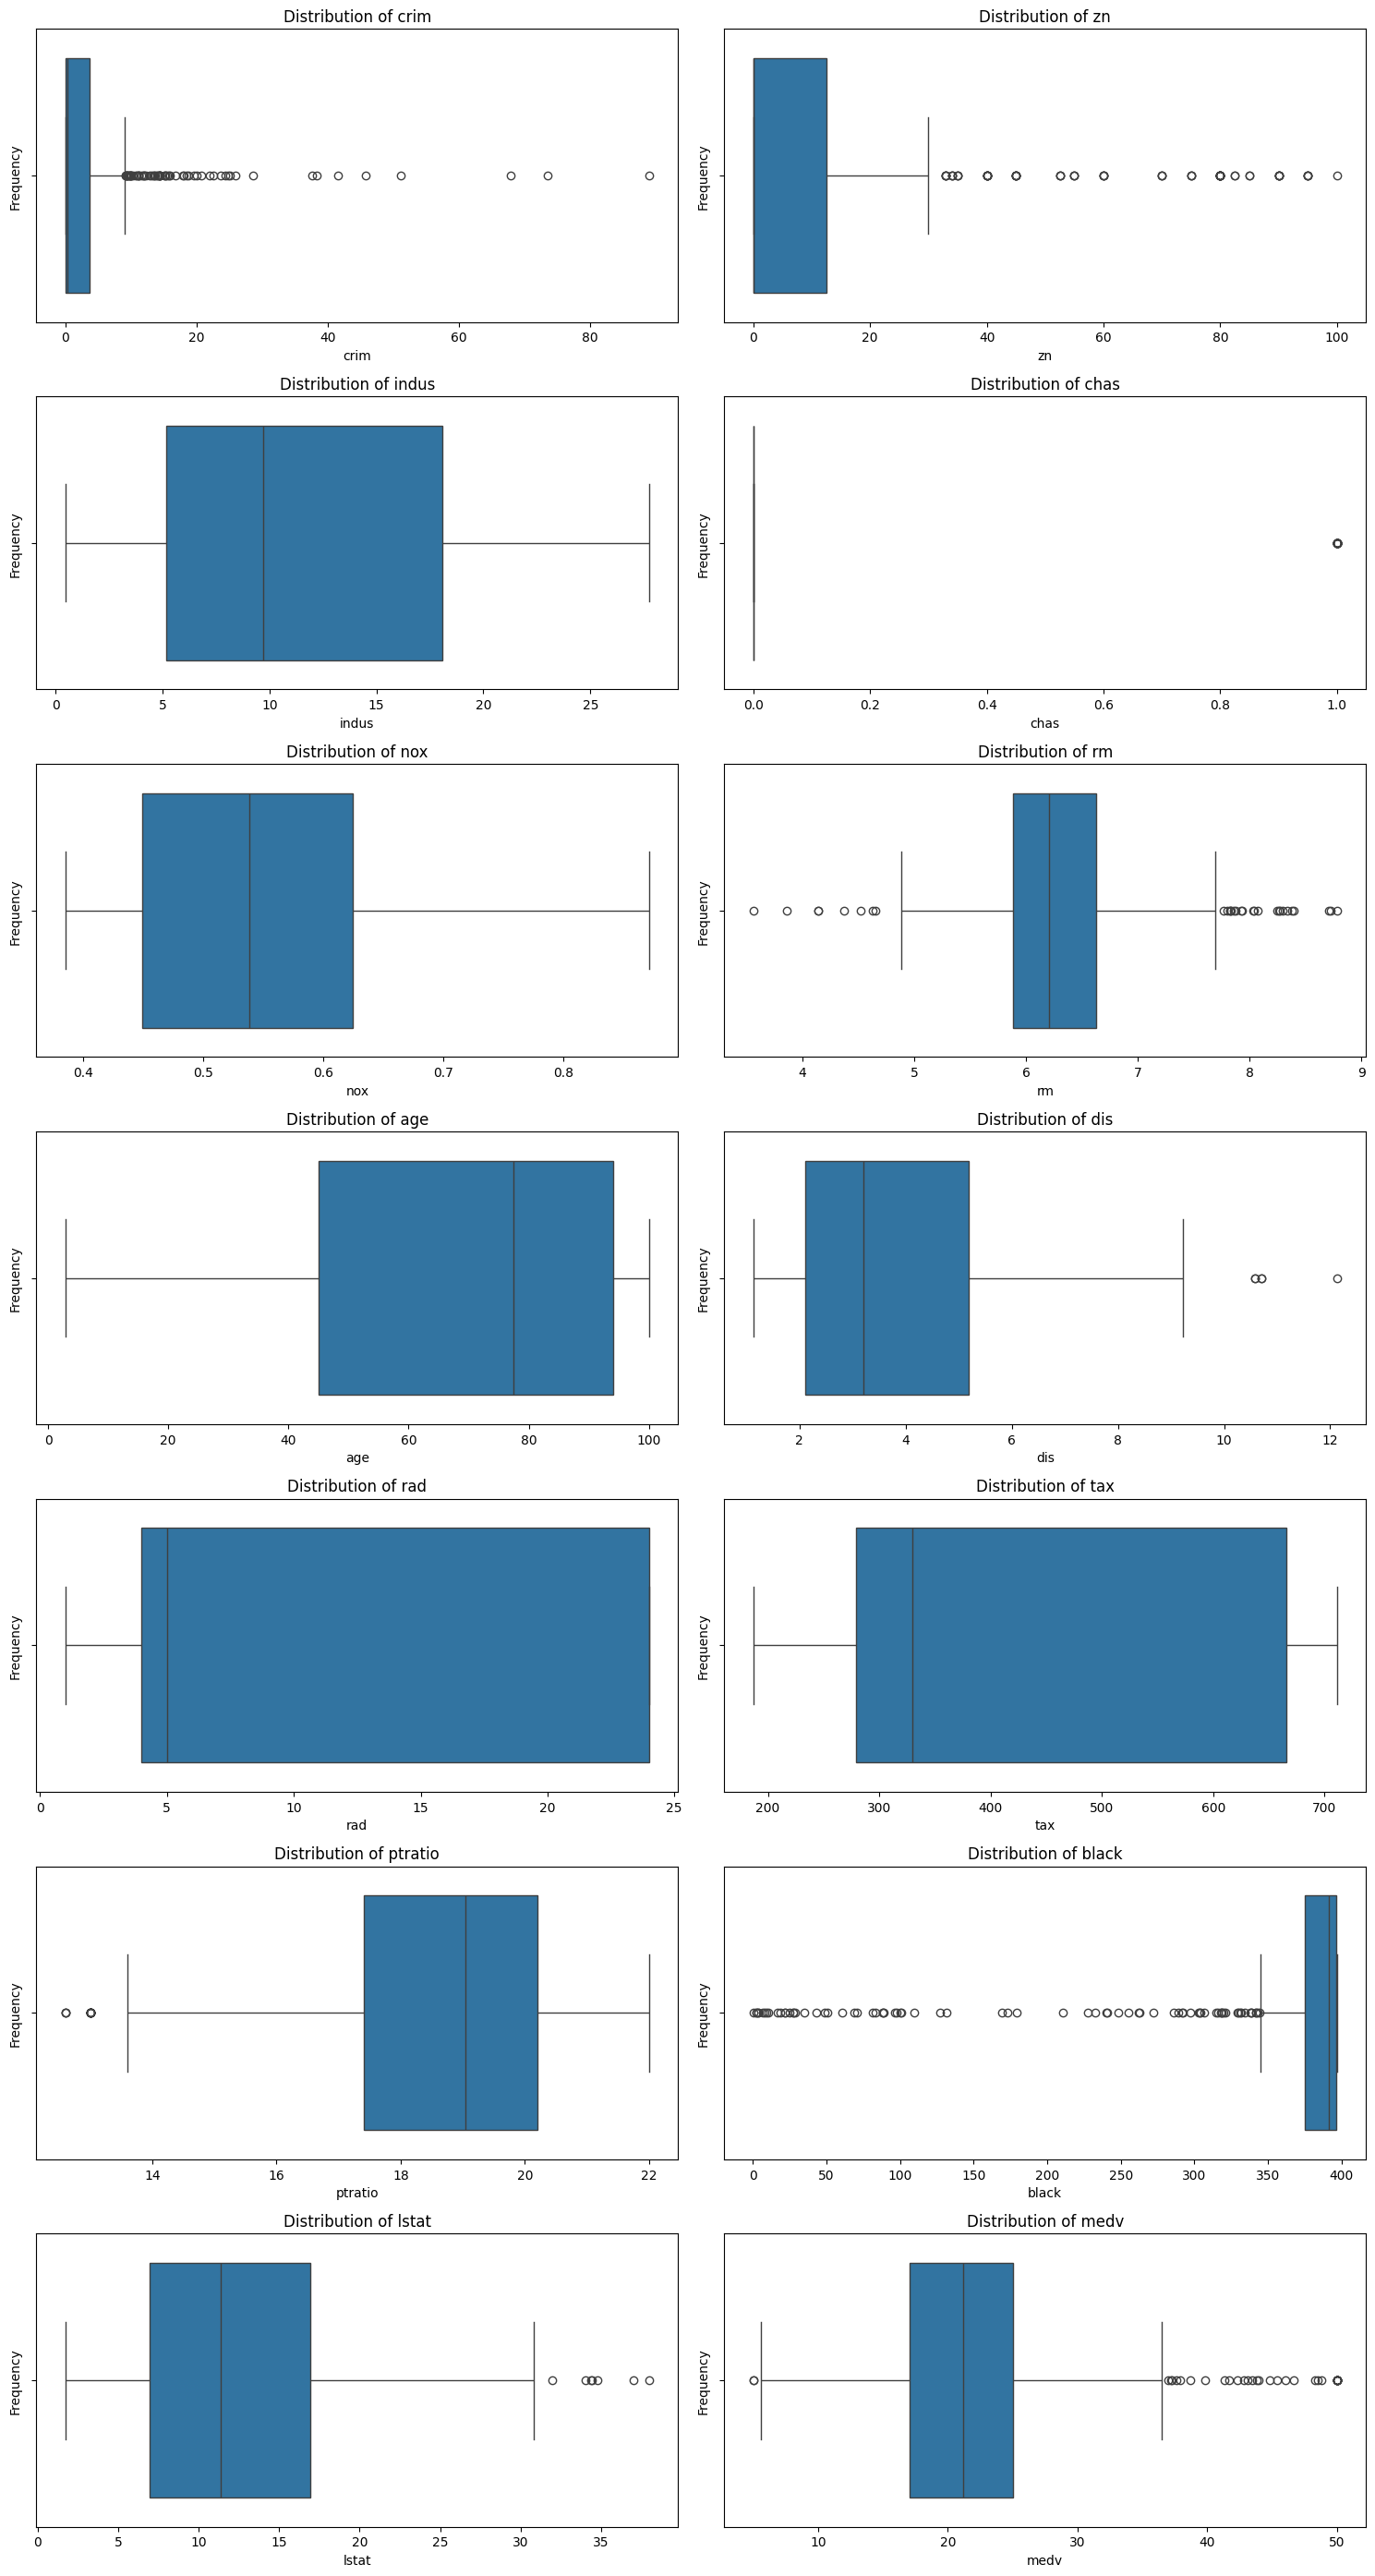

In [254]:
generate_plot(df, plot='boxplot')

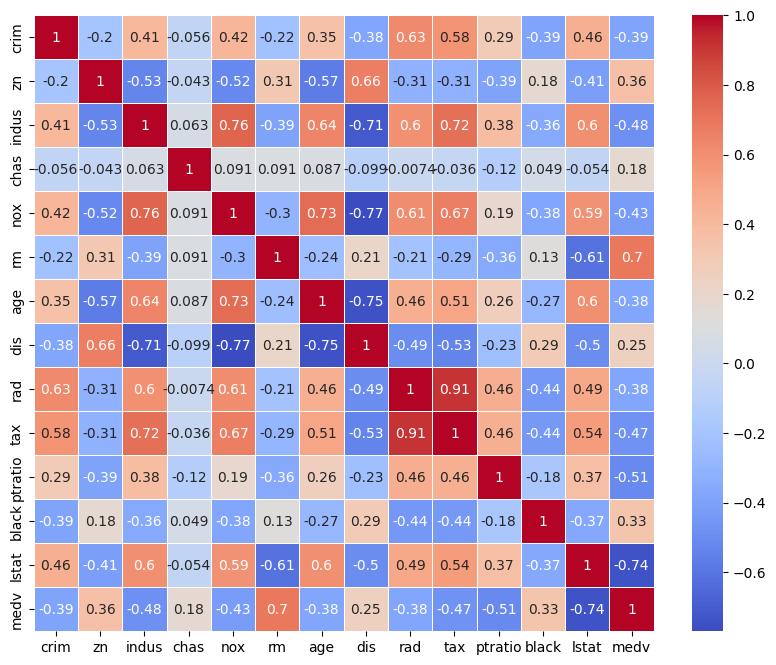

In [255]:
# Correlation Heatmap
corr_matrix = df.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.show()

### Machine Learning
- Train three models (mentioned above) to predict the "medv"
- Evaluate using metrics: MSE, MAE, and R^2 Score

- Import the models

In [256]:
from sklearn.model_selection import train_test_split

target = 'medv'
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)
# Feature and target
X_train = train_df[df.columns.drop(target)]
y_train = train_df[target]
X_test = test_df[df.columns.drop(target)]
y_test = test_df[target]

- Train the Regression tree model

In [257]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

def train_regression_model(model, X_train, y_train, X_test, y_test):
  model.fit(X_train, y_train)
  y_pred = model.predict(X_test)

  print(f"MSE: {mean_squared_error(y_test, y_pred)}")
  print(f"MAE: {mean_absolute_error(y_test, y_pred)}")
  print(f"R^2 Score: {r2_score(y_test, y_pred)}")
  # Prediction for the first 10 testing samples
  print("Prediction for the first 10 testing samples:")
  true_label, pred_label = [], []
  for i in range(10):
    true_label.append(y_test.iloc[i])
    pred_label.append(y_pred[i])

  print(f"True Label: {np.array(true_label)}")
  print(f"Predicted Label: {np.array(pred_label)}")


print("Model 1: Decision Tree Regressor")
train_regression_model(DecisionTreeRegressor(), X_train, y_train, X_test, y_test)
print("\nModel 2: Support Vector Regressor")
train_regression_model(SVR(), X_train, y_train, X_test, y_test)

Model 1: Decision Tree Regressor
MSE: 10.404019607843138
MAE: 2.446078431372549
R^2 Score: 0.8581278755918295
Prediction for the first 10 testing samples:
True Label: [23.6 32.4 13.6 22.8 16.1 20.  17.8 14.  19.6 16.8]
Predicted Label: [28.1 33.1 15.2 21.7 23.2 19.5 16.6 16.6 22.7 22. ]

Model 2: Support Vector Regressor
MSE: 52.8383657679667
MAE: 4.530585721759495
R^2 Score: 0.27948125010200275
Prediction for the first 10 testing samples:
True Label: [23.6 32.4 13.6 22.8 16.1 20.  17.8 14.  19.6 16.8]
Predicted Label: [22.5061509  24.44637611 15.48342923 23.47861138 15.85575665 20.41359379
 22.22729603 19.30750829 16.00684204 20.69013802]


In [258]:
# For the Gaussian Naive Bayes model, we will categorize the target label
# Segmentation technique using pd.qcut()
df['medv_category'] = pd.qcut(df[target], q=5, labels=False)
target = 'medv_category'
# Now drop the "medv"
df = df.drop(columns=["medv"])
# Print the group
df.groupby('medv_category').mean()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat
medv_category,,,,,,,,,,,,,
0,12.738894,0.122549,17.466765,0.019608,0.671873,5.874294,93.856863,2.114959,18.735294,596.539216,19.926471,275.420392,22.007843
1,2.339180,5.495050,12.800990,0.049505,0.582018,5.947970,79.971287,3.657932,8.762376,418.247525,19.025743,355.786337,15.470495
2,1.273985,7.871287,10.941584,0.089109,0.527960,6.100703,61.843564,4.178073,7.871287,377.000000,18.763366,385.024158,11.473663
3,0.993708,14.658416,8.847327,0.069307,0.500030,6.311277,52.130693,4.645998,6.623762,342.792079,18.061386,380.111980,8.805050
4,0.631501,28.782178,5.564554,0.118812,0.490435,7.192990,54.821782,4.394886,5.663366,304.742574,16.486139,387.831782,5.415644


In [259]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   crim           506 non-null    float64
 1   zn             506 non-null    float64
 2   indus          506 non-null    float64
 3   chas           506 non-null    int64  
 4   nox            506 non-null    float64
 5   rm             506 non-null    float64
 6   age            506 non-null    float64
 7   dis            506 non-null    float64
 8   rad            506 non-null    int64  
 9   tax            506 non-null    int64  
 10  ptratio        506 non-null    float64
 11  black          506 non-null    float64
 12  lstat          506 non-null    float64
 13  medv_category  506 non-null    int64  
dtypes: float64(10), int64(4)
memory usage: 55.5 KB


In [260]:
from sklearn.metrics import accuracy_score, classification_report
from sklearn.naive_bayes import GaussianNB

def train_classification_model(model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
    print(classification_report(y_test, y_pred))

    # Prediction for the first 10 testing samples
    print("Prediction for the first 10 testing samples:")
    true_label, pred_label = [], []
    for i in range(10):
      true_label.append(y_test.iloc[i])
      pred_label.append(y_pred[i])

    print(f"True Label: {np.array(true_label)}")
    print(f"Predicted Label: {np.array(pred_label)}")

In [261]:
# Now train the Gaussian NB model
print("Model 3: Gaussian Naive Bayes")
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)
# Feature and target
X_train = train_df[df.columns.drop(target)]
y_train = train_df[target]
X_test = test_df[df.columns.drop(target)]
y_test = test_df[target]

train_classification_model(GaussianNB(), X_train, y_train, X_test, y_test)

Model 3: Gaussian Naive Bayes
Accuracy: 0.49019607843137253
              precision    recall  f1-score   support

           0       0.58      0.86      0.69        22
           1       0.38      0.12      0.19        24
           2       0.43      0.60      0.50        20
           3       0.50      0.14      0.22        21
           4       0.48      0.87      0.62        15

    accuracy                           0.49       102
   macro avg       0.47      0.52      0.44       102
weighted avg       0.47      0.49      0.43       102

Prediction for the first 10 testing samples:
True Label: [3 4 0 3 1 2 1 0 1 1]
Predicted Label: [4 4 0 3 0 2 2 0 0 2]
